# Problem 9.3 Predicting Prices of Used Cars (Regression Trees). 

The dataset __ToyotaCorolla.csv__ contains the data on used cars (Toyota Corolla) on sale during late summer of 2004 in the Netherlands. It has 1436 records containing details on 38 attributes, including Price, Age, Kilometers, HP, and other specifications. The goal is to predict the price of a used Toyota Corolla based on its specifications. (The example in Section 9.7 is a subset of this dataset).

In [5]:
!python --version
#!pip install mlba

Python 3.13.5
   ---------------------------------------- 0.0/18.6 MB ? eta -:--:--
   --- ------------------------------------ 1.8/18.6 MB 15.9 MB/s eta 0:00:02
   ----------- ---------------------------- 5.2/18.6 MB 15.4 MB/s eta 0:00:01
   --------------- ------------------------ 7.3/18.6 MB 14.7 MB/s eta 0:00:01
   ---------------------- ----------------- 10.5/18.6 MB 14.7 MB/s eta 0:00:01
   ----------------------------- ---------- 13.6/18.6 MB 14.2 MB/s eta 0:00:01
   --------------------------------- ------ 15.7/18.6 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------  18.4/18.6 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 18.6/18.6 MB 12.8 MB/s eta 0:00:00


In [15]:
import mlba
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import plot_tree, DecisionTreeClassifier, DecisionTreeRegressor
import matplotlib.pylab as plt

%matplotlib inline

__9.3.a.__ Run a full-grown regression tree (RT) with outcome variable Price and predictors Age_08_04, KM, Fuel_Type (first convert to dummies), HP, Automatic, Doors, Quarterly_Tax, Mfr_Guarantee, Guarantee_Period, Airco, Automatic_airco, CD_Player, Powered_Windows, Sport_Model, and Tow_Bar. Set random_state=1.

__9.3.a.i.__ Which appear to be the three or four most important car specifications for predicting the car’s price?

In [8]:
car_df = mlba.load_data('ToyotaCorolla.csv')

columns = [
    "Price",
    "Age_08_04",
    "KM",
    "Fuel_Type",
    "HP",
    "Automatic",
    "Doors",
    "Quarterly_Tax",
    "Mfr_Guarantee",
    "Guarantee_Period",
    "Airco",
    "Automatic_airco",
    "CD_Player",
    "Powered_Windows",
    "Sport_Model",
    "Tow_Bar",
]

car_df = car_df[columns]

car_df = pd.get_dummies(car_df, drop_first=True)

car_df.head()

,Price,Age_08_04,KM,HP,Automatic,Doors,Quarterly_Tax,Mfr_Guarantee,Guarantee_Period,Airco,Automatic_airco,CD_Player,Powered_Windows,Sport_Model,Tow_Bar,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,3,210,0,3,0,0,0,1,0,0,True,False
1,13750,23,72937,90,0,3,210,0,3,1,0,1,0,0,0,True,False
2,13950,24,41711,90,0,3,210,1,3,0,0,0,0,0,0,True,False
3,14950,26,48000,90,0,3,210,1,3,0,0,0,0,0,0,True,False
4,13750,30,38500,90,0,3,210,1,3,1,0,0,1,0,0,True,False


In [13]:
X = car_df.drop(columns=["Price"])
y = car_df['Price']

train_X, holdout_X, train_y, holdout_y = train_test_split(X, y, test_size = 0.4, random_state = 1)

print(f"Train shape: {train_X.shape}, {train_y.shape}")
print(f"Holdout shape: {holdout_X.shape}, {holdout_y.shape}")

Train shape: (861, 16), (861,)
Holdout shape: (575, 16), (575,)


743


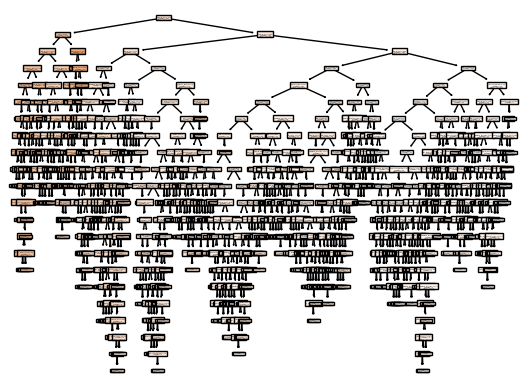

In [18]:
# Make decision tree
reg_tree = DecisionTreeRegressor(random_state=1)
reg_tree.fit(train_X, train_y)

print(reg_tree.get_n_leaves()) # a lot of leaves

plot_tree(reg_tree, feature_names=train_X.columns, impurity=False, filled=True)
plt.show()

In [25]:
#importances = reg_tree.feature_importances_
#print(importances)
importances = pd.DataFrame({'features': train_X.columns, 'importance' : reg_tree.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
importances

,features,importance
0,Age_08_04,0.844867
2,HP,0.053789
1,KM,0.049601
9,Automatic_airco,0.013358
5,Quarterly_Tax,0.006769
11,Powered_Windows,0.005221
4,Doors,0.004864
8,Airco,0.004727
12,Sport_Model,0.004459
6,Mfr_Guarantee,0.003714


The top 4 most important features for predicting car prices are Age_08_04, KM, HP, and Automatic_airco.

__9.3.a.ii.__ Compare the prediction errors of the training and holdout sets by examining their RMS error and by plotting the two boxplots. How does the predictive performance of the holdout set compare to the training set? Why does this occur?

In [ ]:
reg_tree_h = DecisionTreeRegressor(random_state=1)
reg_tree_h = reg_tree_h.fit(holdout_X, holdout_y)